<a href="https://colab.research.google.com/github/BhavyaKyasani/Hospital-Command-Center-Analysis/blob/main/Bed_Occupancy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set(font_scale=1)

import warnings
warnings.filterwarnings("ignore")

In [ ]:
path = "/content/bed_occupancy_dataset_FINAL_10000 (1).csv"

df = pd.read_csv(path)

In [ ]:
print("Rows and Columns:", df.shape)

Rows and Columns: (10000, 10)


In [ ]:
print("First 5 Rows")
display(df.head())

print("Last 5 Rows")
display(df.tail())

First 5 Rows


,Date_Time,Total_Beds,Occupied_Beds,Available_Beds,ICU_Beds,ICU_Occupied,Ward,Department,Ventilator_Usage,Emergency_Load
0,2026-01-20 15:19:12,202,145,57,47,40,Ward-A,Cardiology,4,Medium
1,2026-02-15 22:52:34,207,146,61,21,7,Ward-A,ICU,25,Medium
2,2026-03-01 13:50:29,84,75,9,18,6,Emergency,General,24,Medium
3,2026-03-03 14:45:37,275,250,25,22,8,ICU,Cardiology,10,Low
4,2026-05-06 07:30:57,238,157,81,11,8,Ward-B,Neurology,5,Medium


Last 5 Rows


,Date_Time,Total_Beds,Occupied_Beds,Available_Beds,ICU_Beds,ICU_Occupied,Ward,Department,Ventilator_Usage,Emergency_Load
9995,2027-06-04 06:20:14,150,97,53,10,9,ICU,General,2,33
9996,2027-06-04 07:20:14,100,66,34,10,4,ICU,ICU,0,31
9997,2027-06-04 08:20:14,150,94,56,20,13,Ward-B,ICU,10,11
9998,2027-06-04 09:20:14,120,98,22,20,13,Emergency,Cardiology,6,25
9999,2027-06-04 10:20:14,120,77,43,40,35,Ward-B,Neurology,16,12


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Date_Time         10000 non-null  object
 1   Total_Beds        10000 non-null  int64 
 2   Occupied_Beds     10000 non-null  int64 
 3   Available_Beds    10000 non-null  int64 
 4   ICU_Beds          10000 non-null  int64 
 5   ICU_Occupied      10000 non-null  int64 
 6   Ward              10000 non-null  object
 7   Department        10000 non-null  object
 8   Ventilator_Usage  10000 non-null  int64 
 9   Emergency_Load    10000 non-null  object
dtypes: int64(6), object(4)
memory usage: 781.4+ KB


In [ ]:
print(df.dtypes)

Date_Time           object
Total_Beds           int64
Occupied_Beds        int64
Available_Beds       int64
ICU_Beds             int64
ICU_Occupied         int64
Ward                object
Department          object
Ventilator_Usage     int64
Emergency_Load      object
dtype: object


In [ ]:
display(df.describe(include='all'))

,Date_Time,Total_Beds,Occupied_Beds,Available_Beds,ICU_Beds,ICU_Occupied,Ward,Department,Ventilator_Usage,Emergency_Load
count,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000,10000,10000.000000,10000
unique,10000,NaN,NaN,NaN,NaN,NaN,5,5,NaN,54
top,2027-06-03 18:20:14,NaN,NaN,NaN,NaN,NaN,Ward-A,Cardiology,NaN,Medium
freq,1,NaN,NaN,NaN,NaN,NaN,2056,2036,NaN,357
mean,NaN,134.278600,97.781000,36.497600,25.623000,17.379600,NaN,NaN,9.213200,NaN
std,NaN,47.592954,38.947063,28.625638,11.339865,9.584774,NaN,NaN,7.749978,NaN
min,NaN,50.000000,20.000000,0.000000,10.000000,0.000000,NaN,NaN,0.000000,NaN
25%,NaN,100.000000,69.000000,18.000000,20.000000,9.000000,NaN,NaN,3.000000,NaN
50%,NaN,120.000000,89.000000,30.000000,30.000000,16.000000,NaN,NaN,7.000000,NaN
75%,NaN,150.000000,121.000000,47.000000,40.000000,24.000000,NaN,NaN,14.000000,NaN


Missing Values:
Date_Time           0
Total_Beds          0
Occupied_Beds       0
Available_Beds      0
ICU_Beds            0
ICU_Occupied        0
Ward                0
Department          0
Ventilator_Usage    0
Emergency_Load      0
dtype: int64


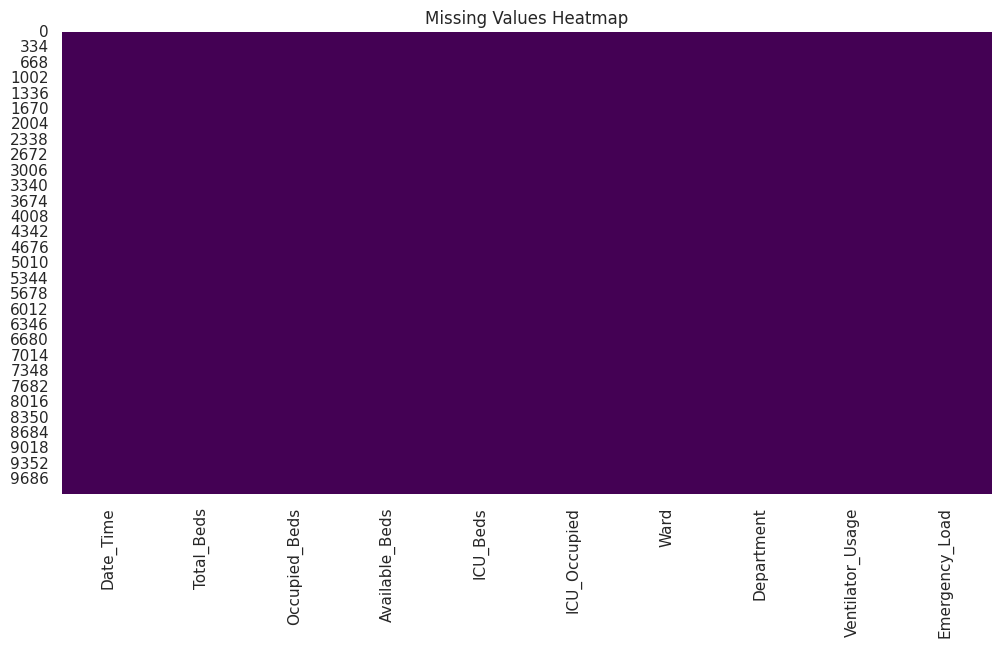

In [ ]:
missing = df.isnull().sum()

print("Missing Values:")
print(missing)

plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

In [ ]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [ ]:
unique = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": df.nunique().values
})

display(unique)

,Column,Unique Values
0,Date_Time,10000
1,Total_Beds,247
2,Occupied_Beds,231
3,Available_Beds,216
4,ICU_Beds,41
5,ICU_Occupied,47
6,Ward,5
7,Department,5
8,Ventilator_Usage,41
9,Emergency_Load,54


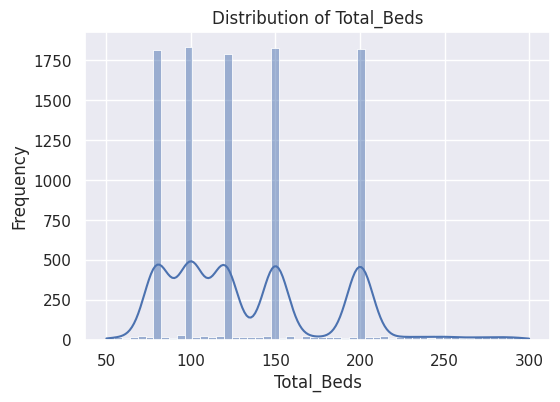

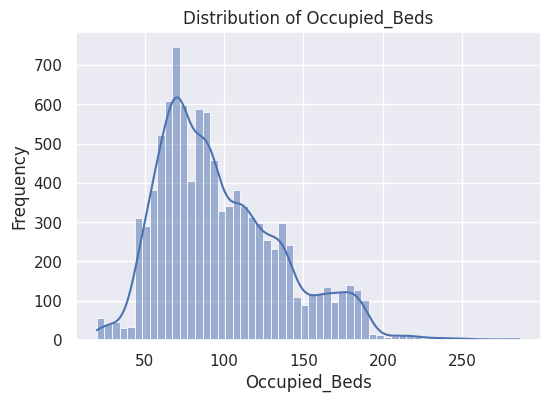

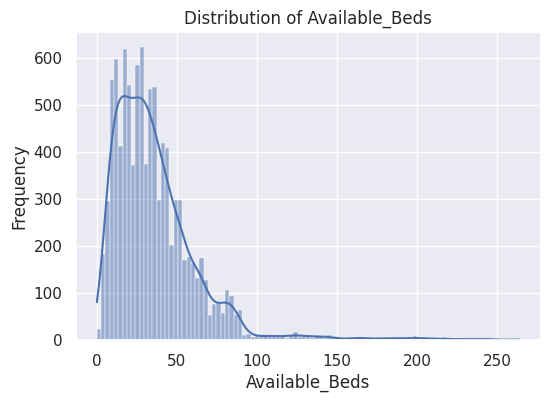

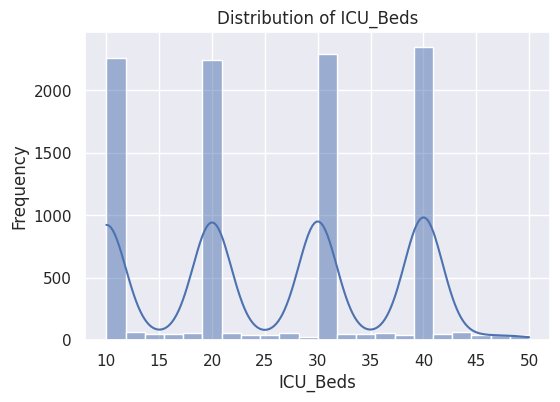

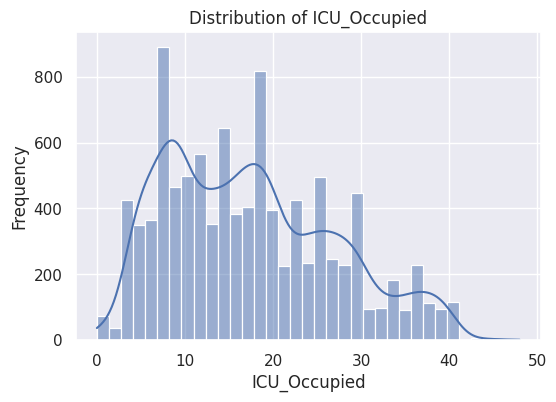

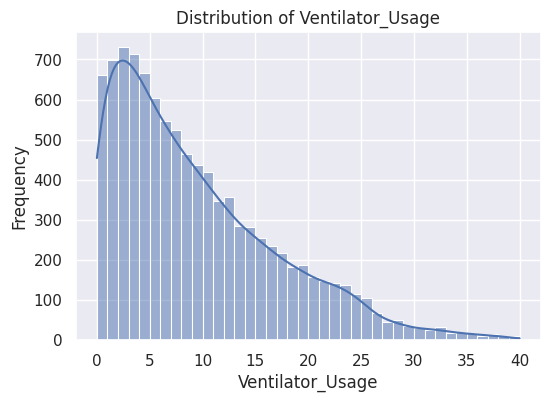

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

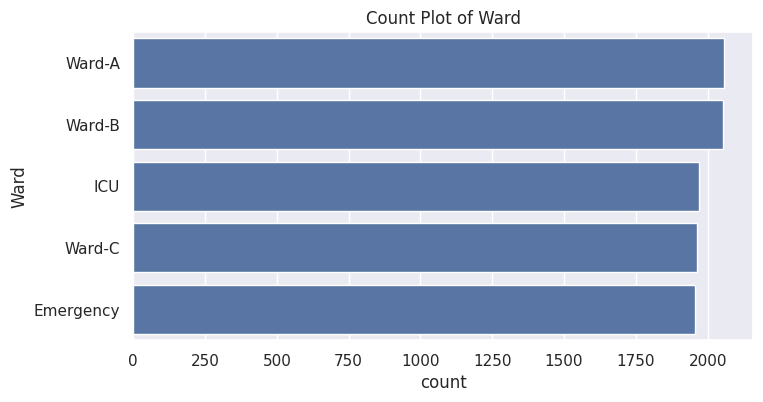

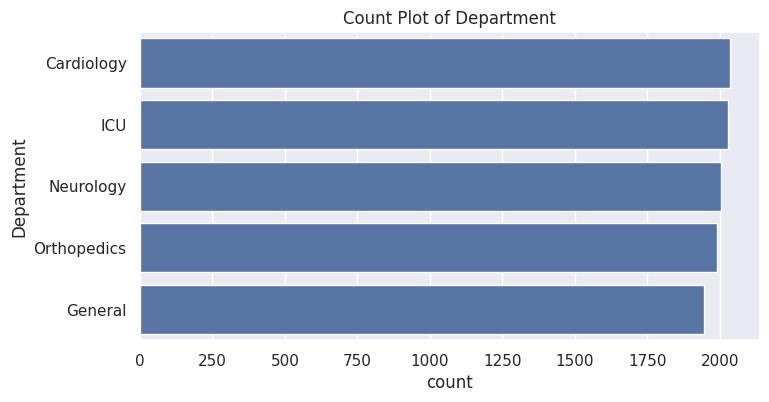

In [ ]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    if df[col].nunique() <= 20:
        plt.figure(figsize=(8,4))
        sns.countplot(y=df[col], order=df[col].value_counts().index)
        plt.title(f"Count Plot of {col}")
        plt.show()

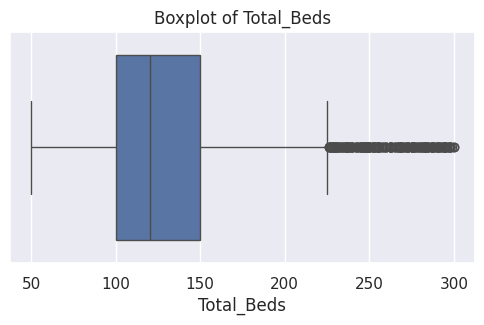

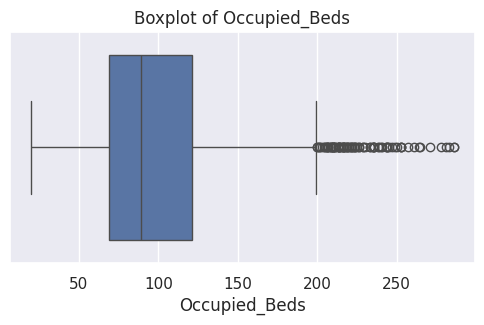

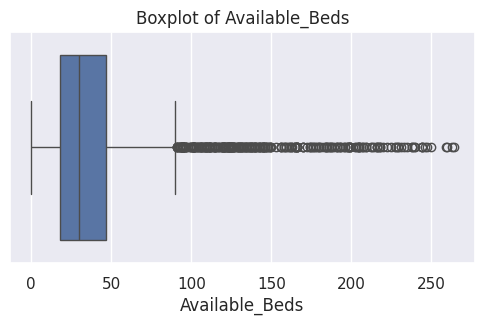

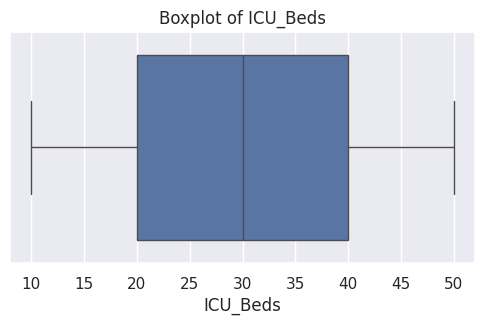

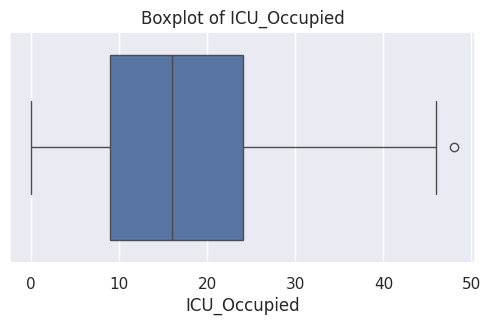

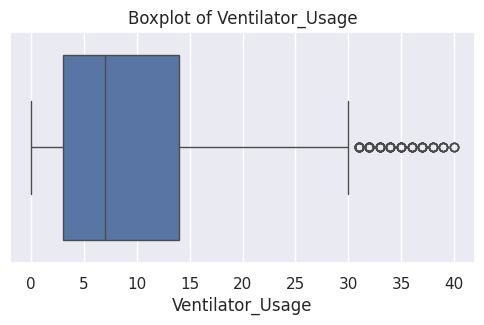

In [ ]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

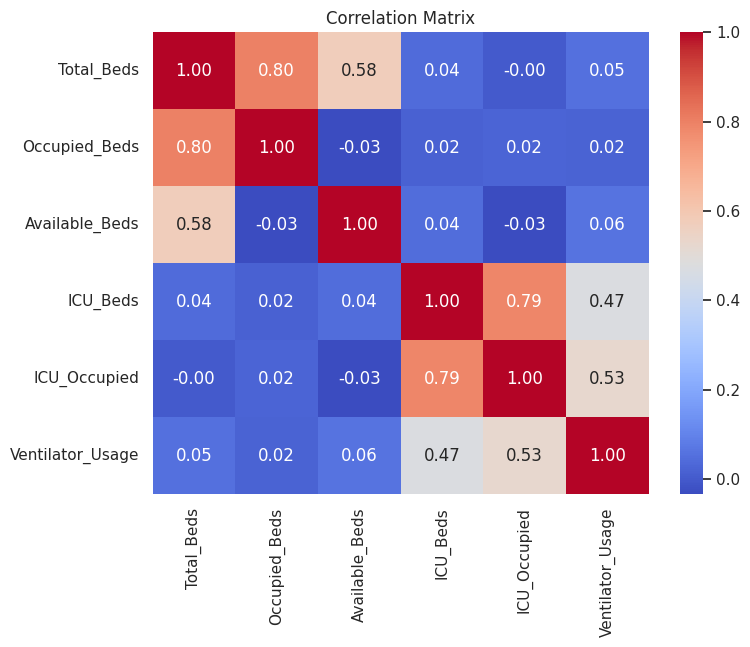

In [ ]:
corr = df[num_cols].corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
clean_df = df.drop_duplicates()

clean_df.to_csv("/content/bed_occupancy_dataset_FINAL_10000_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
